In [454]:
import h5py
import matplotlib.pyplot as plt
import numpy as np 

In [490]:
degree = 4.5
factor = 18
clean = h5py.File("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/horizon_mse_results_fcn-2023-clean_init.h5")
clim = h5py.File("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/horizon_mse_results_fcn-climatology-clim_init.h5")
obs = h5py.File("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/horizon_mse_results_fcn-obs_upscaled-upsc_obs{}.h5".format(factor)) 
analysis = h5py.File("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/horizon_mse_results_fcn-update-filter_init{}_new.h5".format(factor))

In [491]:
initial_3dvar = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_filtering_rmse_factor{}.npy".format(factor,factor))
initial_3dvar_mean = initial_3dvar.mean()
initial_3dvar_spread = [np.quantile(initial_3dvar,0.05, axis = 0), np.quantile(initial_3dvar,0.95, axis = 0)]
upsc_obs = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/rmse_upscaled_obs.npy".format(factor))
upsc_obs_mean = upsc_obs.mean()
upsc_obs_spread = [np.quantile(upsc_obs.mean(axis=(1,2)),0.05, axis = 0), np.quantile(upsc_obs.mean(axis=(1,2)),0.95, axis = 0)]

In [492]:
clim_init = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/climatology_rmse_inits.npy")
clim_init_mean = clim_init.mean()
clim_init_spread = [np.quantile(clim_init.mean(axis=(1,2)), 0.05, axis=0), np.quantile(clim_init.mean(axis=(1,2)), 0.95, axis=0)]

(1460, 1, 20)
(1460, 1, 20)


In [495]:
def plot_avg_features(clean,clean_s, clim, clim_s, obs,obs_s, analysis,analysis_s, min_y, max_y, ylabel, degree, save_fig = None, legend_placemt = None):

    plt.plot(np.arange(0,6*max_t+6,6), clean, c ='green')
    plt.plot(np.arange(0,6*max_t+6,6), clim, c ='purple')
    plt.plot(np.arange(0,6*max_t+6,6), obs, c ='red')
    plt.plot(np.arange(0,6*max_t+6,6), analysis, c = 'blue')
    
    plt.plot([6*max_t], clean[-1], c = 'green', marker = 'o', label = "ERA5 (gold standard)")
    plt.plot([6*max_t], clim[-1], c = 'purple', marker = 'D', label = "Climatology")
    
    plt.plot([6*max_t], obs[-1], c = 'red', marker = 'v', label = "Interpolated {}$^\circ$ Obs.".format(degree))
    plt.plot([6*max_t], analysis[-1], c = 'blue', marker = 's', label = "3DVar Analysis, {}$^\circ$ Obs.".format(degree))
    
    plt.fill_between(np.arange(0,6*max_t+6,6), clean_s[0], clean_s[1], color = 'green', alpha = 0.2 )
    plt.fill_between(np.arange(0,6*max_t+6,6), clim_s[0], clim_s[1], color = 'purple', alpha = 0.2 )
    plt.fill_between(np.arange(0,6*max_t+6,6),  obs_s[0], obs_s[1], color = 'red', alpha = 0.2 )
    plt.fill_between(np.arange(0,6*max_t+6,6), analysis_s[0], analysis_s[1], color = 'blue', alpha = 0.2 )
    plt.ylim((min_y,max_y))
    plt.xlabel("Forecasting Horizon (hours)")
    plt.ylabel("{}".format(ylabel))
    if legend_placemt is not None:
        plt.legend(title = "Forecasting Initialization", bbox_to_anchor=(0.5,0.6))
    else:
        plt.legend(title = "Forecasting Initialization")
    if save_fig is not None:
        plt.savefig("../figures/task2/{}".format(save_fig), 
               bbox_inches='tight', dpi = 300)
    plt.show()

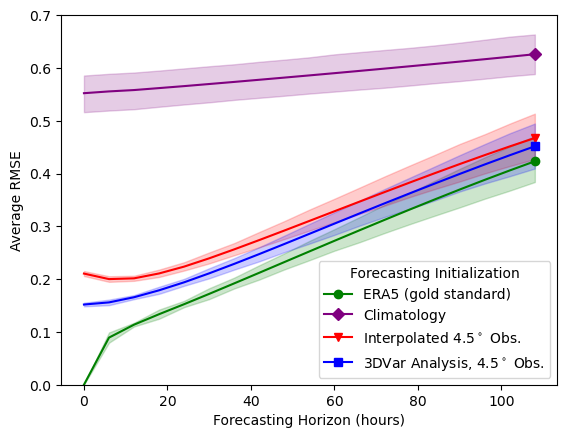

In [496]:
dataset = "horizon_rmse_avg_by_features"
max_t =  18
clean = np.array(clean[dataset])[:,:max_t]#.mean(0)
obs = np.array(obs[dataset])[:,:max_t]#.mean(0)
clim = np.array(clim[dataset])[:,:max_t]#.mean(0)
analysis = np.array(analysis[dataset])[:,:max_t]#.mean(0)

clean_spread = [np.concatenate((np.array([0]), np.quantile(clean,0.05, axis = 0))), np.concatenate((np.array([0]), np.quantile(clean,0.95, axis = 0)))] #/np.sqrt(clean['horizon_rmse_avg_by_features'].shape[0])
clim_spread = [np.concatenate((np.array([clim_init_spread[0]]),np.quantile(clim,0.05, axis = 0))), np.concatenate((np.array([clim_init_spread[1]]), np.quantile(clim,0.95, axis = 0)))]
obs_spread = [np.concatenate((np.array([upsc_obs_spread[0]]), np.quantile(obs,0.05, axis = 0))), np.concatenate((np.array([upsc_obs_spread[1]]), np.quantile(obs,0.95, axis = 0)))]
analysis_spread = [np.concatenate((np.array([initial_3dvar_spread[0]]), np.quantile(analysis,0.05, axis = 0))), np.concatenate((np.array([initial_3dvar_spread[1]]), np.quantile(analysis,0.95, axis = 0)))]

clean_m = np.concatenate((np.array([0]), clean.mean(0)),axis=0)
obs_m = np.concatenate((np.array([upsc_obs_mean]), obs.mean(0)),axis=0)
analysis_m = np.concatenate((np.array([initial_3dvar_mean]), analysis.mean(0)),axis=0)
clim_m = np.concatenate((np.array([clim_init_mean]), clim.mean(0)),axis=0)

plot_avg_features(clean_m, clean_spread, clim_m,clim_spread, obs_m, obs_spread, analysis_m,analysis_spread, 0, 0.7, "Average RMSE", degree, "avg_t_forecast_rmse_obs{}.png".format(factor))

In [497]:
dataset ="horizon_acc_avg_by_features"
clean = h5py.File("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/horizon_mse_results_fcn-2023-clean_init.h5")
clim = h5py.File("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/horizon_mse_results_fcn-climatology-clim_init.h5")
obs = h5py.File("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/horizon_mse_results_fcn-obs_upscaled-upsc_obs{}.h5".format(factor)) 
analysis = h5py.File("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/horizon_mse_results_fcn-update-filter_init{}_new.h5".format(factor))

initial_3dvar = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/enkf_filtering_acc_factor{}.npy".format(factor,factor))
initial_3dvar_mean = initial_3dvar.mean()
initial_3dvar_spread = [np.quantile(initial_3dvar,0.05, axis = 0), np.quantile(initial_3dvar,0.95, axis = 0)]
upsc_obs = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/vary_obs/new_framework_GLOBAL_FCNinterpyHnotIdyLdx_q0.5r0.0001n1woodbury_qfactor{}GLOBALsmooth4_041124/acc_upscaled_obs.npy".format(factor))
upsc_obs_mean = upsc_obs.mean()
upsc_obs_spread = [np.quantile(upsc_obs.mean(axis=(1,2)),0.05, axis = 0), np.quantile(upsc_obs.mean(axis=(1,2)),0.95, axis = 0)]

In [498]:
clim_init = np.load("/pscratch/sd/m/maadrian/output/ERA5/2023/forecasting_errors/climatology_acc_inits.npy")
clim_init_mean = clim_init.mean()
clim_init_spread = [np.quantile(clim_init.mean(axis=(1,2)), 0.05, axis=0), np.quantile(clim_init.mean(axis=(1,2)), 0.95, axis=0)]

In [499]:
clean = np.array(clean[dataset])[:,:max_t]
obs = np.array(obs[dataset])[:,:max_t]
clim = np.array(clim[dataset])[:,:max_t]
analysis = np.array(analysis[dataset])[:,:max_t]

clean_spread = [np.concatenate((np.array([1]), np.quantile(clean,0.05, axis = 0))), np.concatenate((np.array([1]), np.quantile(clean,0.95, axis = 0)))] #/np.sqrt(clean['horizon_rmse_avg_by_features'].shape[0])
clim_spread = [np.concatenate((np.array([clim_init_spread[0]]),np.quantile(clim,0.05, axis = 0))), np.concatenate((np.array([clim_init_spread[1]]), np.quantile(clim,0.95, axis = 0)))]
obs_spread = [np.concatenate((np.array([upsc_obs_spread[0]]), np.quantile(obs,0.05, axis = 0))), np.concatenate((np.array([upsc_obs_spread[1]]), np.quantile(obs,0.95, axis = 0)))]
analysis_spread = [np.concatenate((np.array([initial_3dvar_spread[0]]), np.quantile(analysis,0.05, axis = 0))), np.concatenate((np.array([initial_3dvar_spread[1]]), np.quantile(analysis,0.95, axis = 0)))]

clean_m = np.concatenate((np.array([1]), clean.mean(0)),axis=0)
obs_m = np.concatenate((np.array([upsc_obs_mean]), obs.mean(0)),axis=0)
analysis_m = np.concatenate((np.array([initial_3dvar_mean]), analysis.mean(0)),axis=0)
clim_m = np.concatenate((np.array([clim_init_mean]), clim.mean(0)),axis=0)

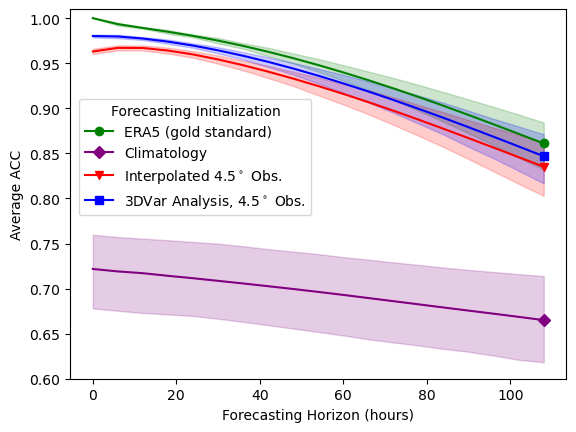

In [500]:
plot_avg_features(clean_m,clean_spread, clim_m,clim_spread, obs_m, obs_spread, analysis_m, analysis_spread, 0.60, 1.01, "Average ACC", degree, "avg_t_forecast_acc_obs{}.png".format(factor),True)